In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flood-area-segmentation' dataset.
Path to dataset files: /kaggle/input/flood-area-segmentation


In [2]:
from pathlib import Path

def print_tree(directory, prefix='', limit=10):
    path_obj = Path(directory)

    try:
        # Get all items and separate them into dirs and files
        items = list(path_obj.iterdir())
        dirs = sorted([x for x in items if x.is_dir()], key=lambda x: x.name.lower())
        files = sorted([x for x in items if x.is_file()], key=lambda x: x.name.lower())
    except PermissionError:
        print(f"{prefix}[Access Denied]")
        return

    # We will print ALL directories, but only a sample of files
    files_to_show = files[:limit]
    remaining_files = len(files) - limit

    # Combine lists for the loop
    # We loop through all dirs + the sample of files
    display_items = dirs + files_to_show

    pointers = [('├── ', '│   '), ('└── ', '    ')]

    for i, item in enumerate(display_items):
        # It is the "last" item only if there are no remaining hidden files
        is_last_item = (i == len(display_items) - 1) and (remaining_files <= 0)

        connector, next_prefix = pointers[1] if is_last_item else pointers[0]

        print(f"{prefix}{connector}{item.name}")

        if item.is_dir():
            print_tree(item, prefix + next_prefix, limit)

    # If we cut off files, print the summary as the true last item
    if remaining_files > 0:
        print(f"{prefix}└── ... ({remaining_files} more files)")


print_tree(path, limit=10)

├── Image
│   ├── 0.jpg
│   ├── 1.jpg
│   ├── 10.jpg
│   ├── 1000.jpg
│   ├── 1001.jpg
│   ├── 1002.jpg
│   ├── 1003.jpg
│   ├── 1004.jpg
│   ├── 1005.jpg
│   ├── 1006.jpg
│   └── ... (280 more files)
├── Mask
│   ├── 0.png
│   ├── 1.png
│   ├── 10.png
│   ├── 1000.png
│   ├── 1001.png
│   ├── 1002.png
│   ├── 1003.png
│   ├── 1004.png
│   ├── 1005.png
│   ├── 1006.png
│   └── ... (280 more files)
└── metadata.csv


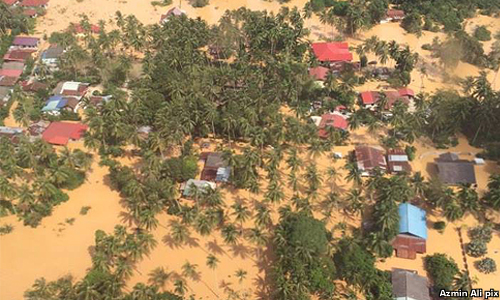

In [11]:
# import os
# from PIL import Image

# # Define the path to the image
# csv_path = os.path.join(path, "Image" , "1.jpg")

# image = Image.open(csv_path)

# image

# # print(csv_path)


In [ ]:
import os
import pandas as pd


# CSV To compine images with its labels



csv_path = os.path.join(path, "metadata.csv")


metadata = pd.read_csv(csv_path)

metadata.head()

,Image,Mask
0,0.jpg,0.png
1,1.jpg,1.png
2,2.jpg,2.png
3,3.jpg,3.png
4,4.jpg,4.png


In [ ]:
import torch
import numpy as np

####### Change the pixel value from 0 122 155 to 0 , 1 and 2 classes becuse
####### CE loss expect classes not any numrical values






def remap_mask(mask):
    # Remaps a mask's pixel values to a consecutive range starting at 0 (Use if Multiclass Segmentation)
    mask = mask.long()
    unique_values = torch.unique(mask)
    remapped_mask = torch.zeros_like(mask)

    for new_val, old_val in enumerate(sorted(unique_values.tolist())):
        remapped_mask[mask == old_val] = new_val

    return remapped_mask

def remap_mask_binary(mask):
    # Remaps a mask's pixel values to a consecutive range starting at 0 (Use if Binary Segmentation)
    mask_np = mask.numpy().squeeze()
    # Convert to binary: non-zero values become 1
    binary_mask = (mask_np != 0).astype(np.uint8)
    return torch.from_numpy(binary_mask).unsqueeze(0)

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import numpy as np
# Custom Dataset Class
class FloodSegmentationDataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None, target_transform=None):
        self.root_dir = root_dir
        self.metadata = pd.read_csv(csv_file)
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):


        ####. For example index 0 will get the path for the image and mask 0
        img_path = os.path.join(self.root_dir, "Image", self.metadata.iloc[idx, 0])   #### Use the csv to get paths
        mask_path = os.path.join(self.root_dir, "Mask", self.metadata.iloc[idx, 1])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Convert mask to grayscale (1 channel = binary segmentation)

        if self.transform:
            image = self.transform(image)

        if self.target_transform:
            mask = self.target_transform(mask)

        # Replace mask values with remapped values
        mask = remap_mask_binary(mask)

        return image, mask       # In image classification datasets, we return image and label. Here, we return image and mask

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Define transforms for images and masks
image_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((256, 256)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard ImageNet normalization
])

mask_transforms = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),  # Keep segmentation masks intact
    transforms.PILToTensor(),

])



# Split dataset into 80% train, 20% test
train_data, test_data = train_test_split(metadata, test_size=0.2, random_state=42, shuffle=True)



# Save split CSVs
train_data.to_csv(os.path.join(path, "train.csv"), index=False)
test_data.to_csv(os.path.join(path, "test.csv"), index=False)




# Load training dataset
train_dataset = FloodSegmentationDataset(root_dir=path, csv_file=os.path.join(path, "train.csv"),
                                         transform=image_transforms, target_transform=mask_transforms)

# Load testing dataset
test_dataset = FloodSegmentationDataset(root_dir=path, csv_file=os.path.join(path, "test.csv"),
                                        transform=image_transforms, target_transform=mask_transforms)


# Create Train & Test DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

# Check dataset sizes
print(f"Training Samples: {len(train_dataset)}, Testing Samples: {len(test_dataset)}")


Training Samples: 232, Testing Samples: 58


In [ ]:
look_path = os.path.join(path, "train.csv")
print(look_path)

/root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/train.csv


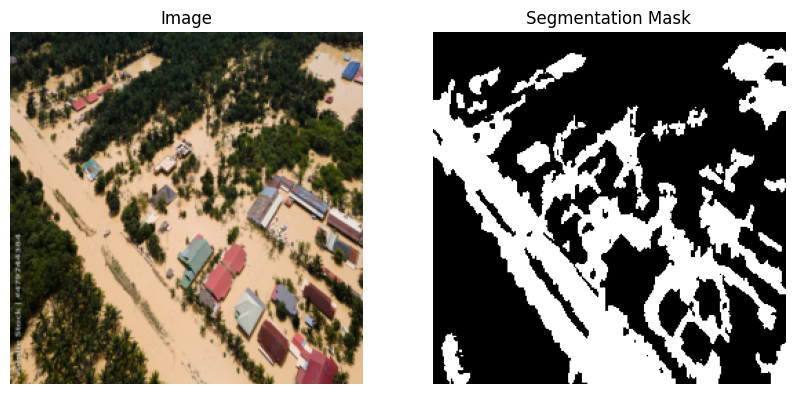

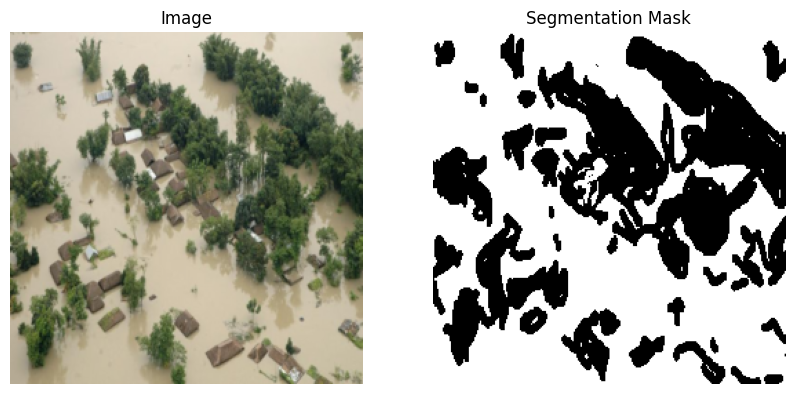

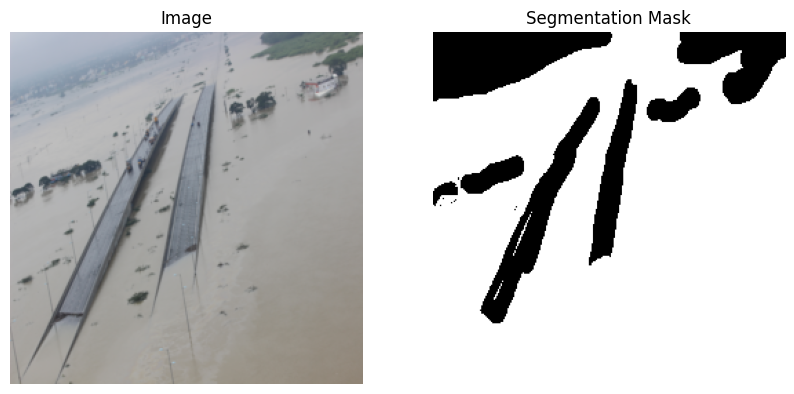

In [ ]:
import matplotlib.pyplot as plt

# Function to denormalize images (We cannot show normalized images. We have to reverse normalizaion first.)
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])  # ImageNet std
    img = img.numpy().transpose(1, 2, 0)  # Convert to HWC
    img = img * std + mean  # Reverse normalization
    img = np.clip(img, 0, 1)  # Clip values to [0,1]
    return img

# Display some images with their masks
for i in range(3):
    img, mask = train_dataset[i]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(denormalize(img))
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(mask.permute(1,2,0), cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")
    plt.show()


In [ ]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    """U-Net model with skip connections (Residuals)."""
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()


      # nn.Sequential is a container that allows you to wrap multiple layers into a single object. It treats them as a pipeline:




        # --- ENCODER ---
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # --- BOTTLENECK ---
        #The bottom of the "U",
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )

        # --- DECODER --- # at each stage of upsampling , Reduce channels , Double the H and W
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2) # Deconvolution , upsampling , To make the image bigger
                                                # F and S double the Hight and Width


        # If up4 just output 512 channels, why does dec4 expect 1024? This is because of Skip Connections (Concatenation).
        self.dec4 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),  # 512 + 512 (residual) = 1024 input channels
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),  # 256 + 256 (residual) = 512 input channels
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),  # 128 + 128 (residual) = 256 input channels
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),  # 64 + 64 (residual) = 128 input channels
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # Final layer
        self.final = nn.Conv2d(64, out_channels, kernel_size=1) # out channels is the classes


        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # --- ENCODER ---
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        # --- BOTTLENECK ---
        bottleneck = self.bottleneck(self.pool(enc4))

        # --- DECODER + SKIP CONNECTIONS ---
        x = self.up4(bottleneck) # reduce the channels and double the images
        x = torch.cat([x, enc4], dim=1) # Do the conncatination between enc4 and x
        # torch.cat joins them together side-by-side. If x has 512 channels and enc4 has 512 channels, the new x now has 1024 channels.
        dec4 = self.dec4(x)





        # Do upsampling --> Reduce channels double H and W
        # Do cancotionantion (Residual) -----> Add reduced channels to x channels
        x = self.up3(dec4)
        x = torch.cat([x, enc3], dim=1)
        dec3 = self.dec3(x)

        x = self.up2(dec3)
        x = torch.cat([x, enc2], dim=1)
        dec2 = self.dec2(x)

        x = self.up1(dec2)
        x = torch.cat([x, enc1], dim=1)
        dec1 = self.dec1(x)

        # --- FINAL LAYER ---
        return self.final(dec1)


In [ ]:
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in tqdm(dataloader):
        images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)  # mask shape becomes [N, H, W]

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)    # mask shape becomes [N, H, W]

            outputs = model(images)  # Now [N, H, W]
            loss = criterion(outputs, masks)
            total_loss += loss.item()

    return total_loss / len(dataloader)





In [ ]:
import torch

# Initialize model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNet(in_channels=3, out_channels=3).to(device)  # Output channels = 3 classes

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

num_epochs = 10  # Define number of epochs
train_losses = []
val_losses = []

# Training Loop
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")


100%|██████████| 58/58 [00:17<00:00,  3.32it/s]


Epoch 1/10: Train Loss = 0.6901, Val Loss = 0.5578


100%|██████████| 58/58 [00:16<00:00,  3.44it/s]


Epoch 2/10: Train Loss = 0.5389, Val Loss = 0.4928


100%|██████████| 58/58 [00:16<00:00,  3.59it/s]


...

Epoch 8/10: Train Loss = 0.3955, Val Loss = 0.3844


100%|██████████| 58/58 [00:17<00:00,  3.35it/s]


Epoch 9/10: Train Loss = 0.3779, Val Loss = 0.3276


100%|██████████| 58/58 [00:15<00:00,  3.66it/s]


Epoch 10/10: Train Loss = 0.3585, Val Loss = 0.3444


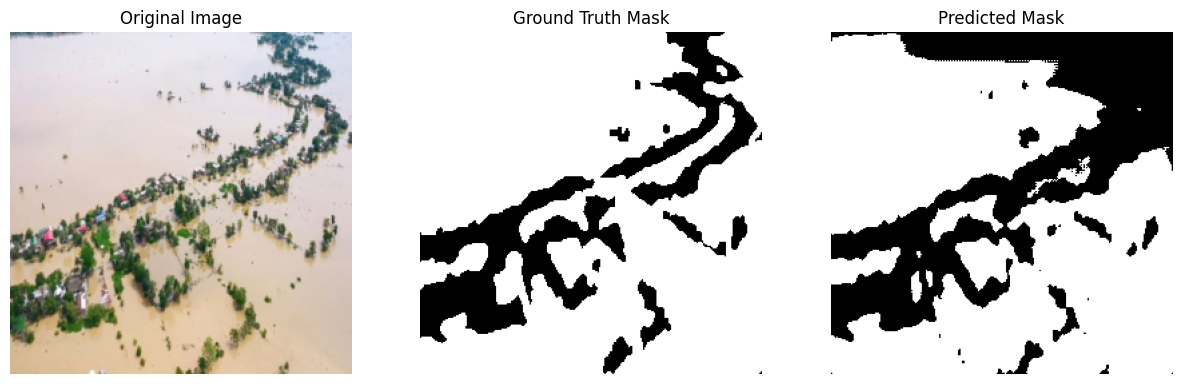

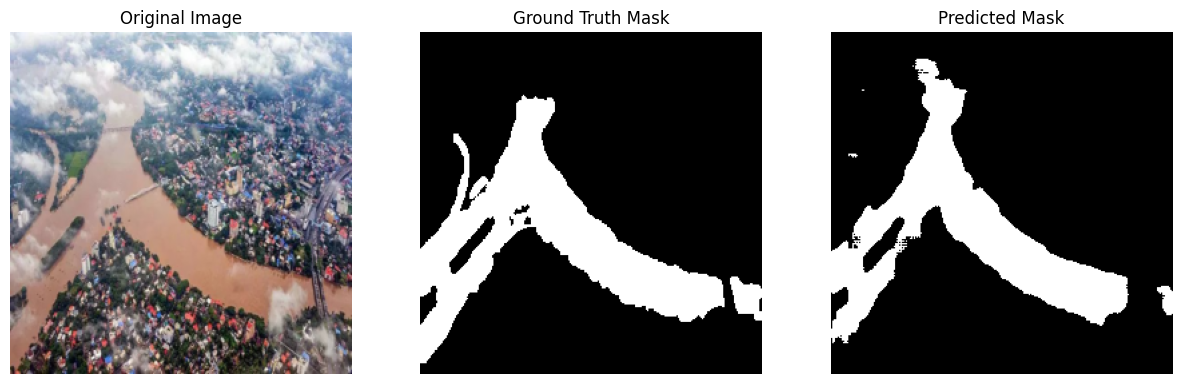

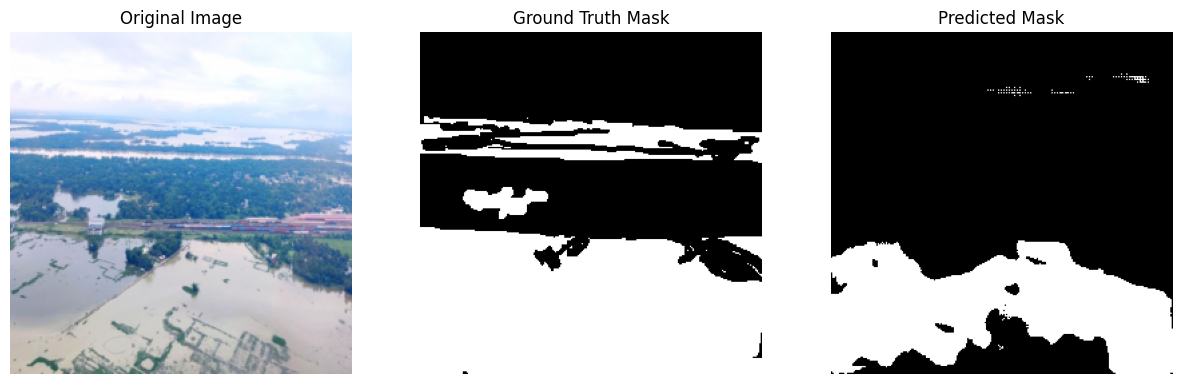

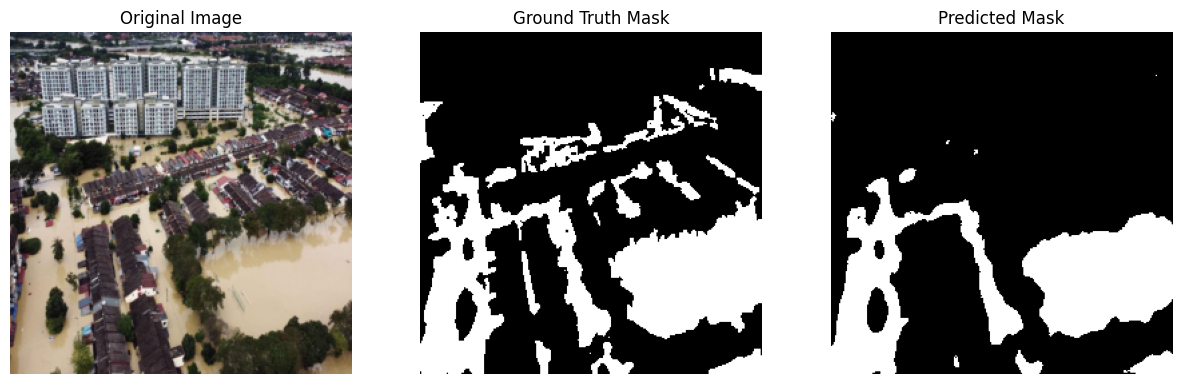

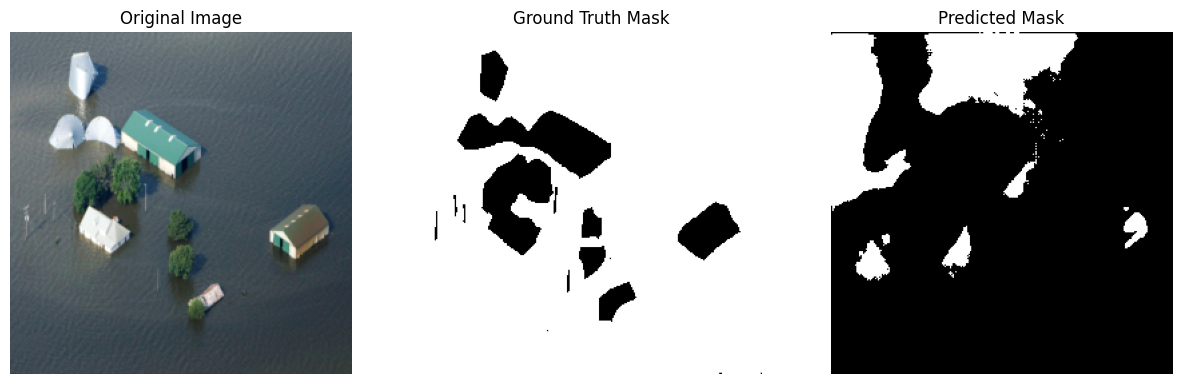

In [ ]:
import random
import matplotlib.pyplot as plt

model.eval()
# Get some test samples
test_samples = random.sample(range(len(test_dataset)), 5)

for idx in test_samples:
    img, mask = test_dataset[idx]

    with torch.no_grad():
        pred_mask = model(img.unsqueeze(0).to(device))  # Forward pass

    pred_mask = torch.softmax(pred_mask, dim=1)  # Convert logits to probabilities
    pred_mask = pred_mask.argmax(dim=1).cpu().squeeze().numpy()  # Get class with highest probability

    # Display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(denormalize(img))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="gray")  # Show class map
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    plt.show()